# BEE2041 Data Science in Economics Empirical Project Analysis

In this Notebook I will be completing the webscraping, data cleaning, data analysis and generation of figures for my empirical project

## Installing and importing libraries

In [1]:
# install the necessary libraries

!pip install requests beautifulsoup4 pandas --break-system-packages
!pip install matplotlib --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# import the necessary libraries into the Jupyter notebook
    # requests: downloads the HTML of a page
    # BeautifulSoup: parses and navigates the HTML structure
    # pandas: used to analyse the data
    # time: used for functions relating to time
    # matplotlib: used to create figures

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Create folders in my directory to save CSVs or figures to later

import os
os.makedirs("data/raw", exist_ok = True)
os.makedirs("data/processed", exist_ok = True)
os.makedirs("figures", exist_ok = True)

## Attempted aproach: Scraping World Athletics

My first attempt to scrape data for my investigation was the scrape directly from the [World Athletics](worldathletics.org) website. This failed because the website loads its data dynamically, which means the data is not available in the raw HTML that requests.get() can access. I could have used Selenium to scrape the World Athletics website but this would prove very complicated.

In [4]:
# This is the URL of the webpage I'll be scraping for data
url = "https://worldathletics.org/stats-zone"

# # Send a GET request to the WorldAthletics website; this is grabbing data from the website
# returns a response object which contains the HTML content of the page as a string (response.text) and the HTTP status code (tells me whether the request worked or not)
response = requests.get(url)

# Covert the raw HTML into a structured object using BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")

# Extracting the data
# rows = soup.find_all("pre")[0].text.split("\n")
# This line returns an error "list index out of range", which means I am trying to access an item in a position that does not exist.

print(soup.find_all("pre"))
# returns an empty list, meaning there are no <pre> tags; there is no data in the HTML requests.get() downloaded.

[]


When I press CTRL+U while on the WorldAthletics page in my browser, this shows the raw HTML of the website. If I search within this raw HTML for a known athlete's name (for example Usain Bolt), it returns nothing. This means the data is not in the HTML and the page is loaded dynamically. JavaScript is the most common reason for this. 
A webpage being loaded dynamically means the data arrives separately from the HTML. The problem with trying to scrape using requests.get() is it only grabs the HTML, which is empty, and stops there so it never sees the data.

## I'm now going to scrape the [Alltime Athletics](https://www.alltime-athletics.com/) website instead of the World Athletics website.

When using the same (CTRL+U) method to investigate the alltime athletics website, I can see athlete names within the raw HTML. This means the webpage is statically loaded and requests.get() will be able to see all the data.

## Webscraping

### Scraping for female data
I'm going to begin by scraping only the female data in the:
* Sprint events
    * 100m
    * 200m
    * 400m
* Endurance events
    * 1500m
    * 5000m
    * 10000m

I'm going to start by only scraping one event (100m) to ensure my logic is sound

In [5]:
# Assigning the URL of the webpage I'll be scraping to a variable

url_100W = "https://www.alltime-athletics.com/w_100ok.htm"

In [6]:
# Send a HTTP GET request to Alltime Athletics

response_100W = requests.get(url_100W)

In [7]:
# Converting the raw HTML to a structured, searchable object

soup_100W = BeautifulSoup(response_100W.text, "html.parser")

In [8]:
# Creating usable data rows

pre_tag_100W = soup_100W.find("pre")

rows_100W = pre_tag_100W.text.split("\n")

In [9]:
# How many rows are there and what do they look like?

print(len(rows_100W))
print(rows_100W[:5])

3411
['', '        1      10.54      +0.9    Elaine Thompson-Herah          JAM     28.06.92    1      Eugene                     21.08.2021', '        2      10.60      +1.7    Shelly-Ann Fraser-Pryce        JAM     27.12.86    1rA    Lausanne                   26.08.2021', '        3      10.61      +1.2    Florence Griffith-Joyner       USA     21.12.59    1      Indianapolis               17.07.1988', '        3      10.61      -0.6    Elaine Thompson-Herah          JAM     28.06.92    1      Tokyo                      31.07.2021']


In [10]:
# Print the first 5 rows raw so I can see exactly what I'm working with

for row in rows_100W[:5]:
    print(repr(row))
    print(row.split())
    print()

''
[]

'        1      10.54      +0.9    Elaine Thompson-Herah          JAM     28.06.92    1      Eugene                     21.08.2021'
['1', '10.54', '+0.9', 'Elaine', 'Thompson-Herah', 'JAM', '28.06.92', '1', 'Eugene', '21.08.2021']

'        2      10.60      +1.7    Shelly-Ann Fraser-Pryce        JAM     27.12.86    1rA    Lausanne                   26.08.2021'
['2', '10.60', '+1.7', 'Shelly-Ann', 'Fraser-Pryce', 'JAM', '27.12.86', '1rA', 'Lausanne', '26.08.2021']

'        3      10.61      +1.2    Florence Griffith-Joyner       USA     21.12.59    1      Indianapolis               17.07.1988'
['3', '10.61', '+1.2', 'Florence', 'Griffith-Joyner', 'USA', '21.12.59', '1', 'Indianapolis', '17.07.1988']

'        3      10.61      -0.6    Elaine Thompson-Herah          JAM     28.06.92    1      Tokyo                      31.07.2021'
['3', '10.61', '-0.6', 'Elaine', 'Thompson-Herah', 'JAM', '28.06.92', '1', 'Tokyo', '31.07.2021']



In [11]:
# Converting rows of data into a DataFrame

data_100W = []

for row in rows_100W:
    # Split the row by spaces
    parts = row.split()
    # Skip rows without enough elements (I have 9 variables) or header rows
    if len(parts) < 9 or not parts[0].isdigit():
        continue
    try:
        # the columns I know the index of for certain
        rank = parts[0]
        mark = parts[1]
        year = parts[-1]
        # Athlete is everything between columns 3 and 5
        athlete = " ".join(parts[3:-5])
        
        data_100W.append([rank, mark, athlete, year])
    # if anything fails, skip the row and carry on
    except:
        continue

df_100W = pd.DataFrame(data_100W, columns = ["Rank", "Time", "Athlete", "Year"])

In [12]:
# Checking the structure of the DataFrame

print(df_100W.info())

<class 'pandas.DataFrame'>
RangeIndex: 3408 entries, 0 to 3407
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     3408 non-null   str  
 1   Time     3408 non-null   str  
 2   Athlete  3408 non-null   str  
 3   Year     3408 non-null   str  
dtypes: str(4)
memory usage: 106.6 KB
None


In [13]:
df_100W.head()

,Rank,Time,Athlete,Year
0,1,10.54,Elaine Thompson-Herah,21.08.2021
1,2,10.60,Shelly-Ann Fraser-Pryce,26.08.2021
2,3,10.61,Florence Griffith-Joyner,17.07.1988
3,3,10.61,Elaine Thompson-Herah,31.07.2021
4,3,10.61,Melissa Jefferson-Wooden,14.09.2025


In [14]:
# Checking for lost data: How many rows did I lose?

#Count the number of valid rows on AllTimeAthletics
valid_rows_100W = []

for row in rows_100W:
    parts = row.split()
    if len(parts) >= 9 and parts[0].isdigit():
        valid_rows_100W.append(row)

print("Estimated valid rows:", len(valid_rows_100W))

# Compare rows before and after parsing:
print("Valid rows before parsing:", len(valid_rows_100W))
print("Successfully parsed rows:", len(data_100W))

Estimated valid rows: 3408
Valid rows before parsing: 3408
Successfully parsed rows: 3408


In [15]:
# Adding an event and gender column to be able to differentiate the rows later when I combine different events and genders into one CSV file.

df_100W["Event"] = "100m"
df_100W["Gender"] = "Female"

In [16]:
df_100W.head()

,Rank,Time,Athlete,Year,Event,Gender
0,1,10.54,Elaine Thompson-Herah,21.08.2021,100m,Female
1,2,10.60,Shelly-Ann Fraser-Pryce,26.08.2021,100m,Female
2,3,10.61,Florence Griffith-Joyner,17.07.1988,100m,Female
3,3,10.61,Elaine Thompson-Herah,31.07.2021,100m,Female
4,3,10.61,Melissa Jefferson-Wooden,14.09.2025,100m,Female


Now I'll scrape all the remaining events at the same time (200m, 400m, 1500m, 5000m and 10000m) to avoid repitition.

In [17]:
# To avoid having to repeat all these steps for each event and gender:
# Create a dictionary of all required events

eventsW = {
    "200m": "https://www.alltime-athletics.com/w_200ok.htm",
    "400m": "https://www.alltime-athletics.com/w_400ok.htm",
    "1500m": "https://www.alltime-athletics.com/w_1500ok.htm",
    "5000m": "https://www.alltime-athletics.com/w_5000ok.htm",
    "10000m": "https://www.alltime-athletics.com/w_10kok.htm"
}

In [18]:
#

dfs_W = []
for event_name, url in eventsW.items():
    print(f"Scraping {event_name}...")

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers = headers, timeout = 15)
    soup = BeautifulSoup(response.text, "html.parser")
    pre = soup.find("pre")

    if pre is None:
        print(f" No data found for {event_name}, skipping")
        continue

    rows = pre.text.split("\n")
    data = []

    for row in rows:
        parts = row.split()
        if len(parts) < 9 or not parts[0].isdigit():
            continue
        try:
            rank = parts[0]
            mark = parts[1]
            year = parts[-1]
            athlete = " ".join(parts[3:-5])
            data.append([rank, mark, athlete, year])
        except:
            continue
    df_eventsW = pd.DataFrame(data, columns = ["Rank", "Time", "Athlete", "Year"])
    df_eventsW["Event"] = event_name
    df_eventsW["Gender"] = "Female"

    print(f" {len(df_eventsW)} rows scraped")
    dfs_W.append(df_eventsW)
    # Wait 2 seconds between requests to avoid overwhelming the website
    time.sleep(2)

dfW_all = pd.concat(dfs_W, ignore_index = True)
print(f"\nTotal rows: {len(dfW_all)}")

Scraping 200m...
 2727 rows scraped
Scraping 400m...
 4104 rows scraped
Scraping 1500m...
 3800 rows scraped
Scraping 5000m...
 5532 rows scraped
Scraping 10000m...
 2665 rows scraped

Total rows: 18828


In [19]:
print(dfW_all.info())

<class 'pandas.DataFrame'>
RangeIndex: 18828 entries, 0 to 18827
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     18828 non-null  str  
 1   Time     18828 non-null  str  
 2   Athlete  18828 non-null  str  
 3   Year     18828 non-null  str  
 4   Event    18828 non-null  str  
 5   Gender   18828 non-null  str  
dtypes: str(6)
memory usage: 882.7 KB
None


In [20]:
dfW_all.head()

,Rank,Time,Athlete,Year,Event,Gender
0,1,21.34,Florence Griffith-Joyner,29.09.1988,200m,Female
1,2,21.41,Shericka Jackson,25.08.2023,200m,Female
2,3,21.45,Shericka Jackson,21.07.2022,200m,Female
3,4,21.48,Shericka Jackson,08.09.2023,200m,Female
4,5,21.53,Elaine Thompson-Herah,03.08.2021,200m,Female


In [21]:
# Combine all female event data into one large DataFrame
# I should have (3408 + 18828 = 22,236) entries

dfW_all = pd.concat([dfW_all, df_100W], ignore_index = True)

print(dfW_all.info())

<class 'pandas.DataFrame'>
RangeIndex: 22236 entries, 0 to 22235
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     22236 non-null  str  
 1   Time     22236 non-null  str  
 2   Athlete  22236 non-null  str  
 3   Year     22236 non-null  str  
 4   Event    22236 non-null  str  
 5   Gender   22236 non-null  str  
dtypes: str(6)
memory usage: 1.0 MB
None


In [22]:
# Save the raw female data to a CSV before combining

dfW_all.to_csv("data/raw/female_athletics_raw.csv", index = False)

### Scraping for male data in the: 
* Sprint events
    * 100m
    * 200m
    * 400m
* Endurance events
    * 1500m
    * 5000m
    * 10000m

In [23]:
# Create a dictionary of all event URLs

eventsM = {
    "100m": "https://www.alltime-athletics.com/m_100ok.htm",
    "200m": "https://www.alltime-athletics.com/m_200ok.htm",
    "400m": "https://www.alltime-athletics.com/m_400ok.htm",
    "1500m": "https://www.alltime-athletics.com/m_1500ok.htm",
    "5000m": "https://www.alltime-athletics.com/m_5000ok.htm",
    "10000m": "https://www.alltime-athletics.com/m_10kok.htm"
}

In [24]:
#

dfs_M = []
for event_name, url in eventsM.items():
    print(f"Scraping {event_name}...")

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers = headers, timeout = 15)
    soup = BeautifulSoup(response.text, "html.parser")
    pre = soup.find("pre")

    if pre is None:
        print(f" No data found for {event_name}, skipping")
        continue

    rows = pre.text.split("\n")
    data = []

    for row in rows:
        parts = row.split()
        if len(parts) < 9 or not parts[0].isdigit():
            continue
        try:
            rank = parts[0]
            mark = parts[1]
            year = parts[-1]
            athlete = " ".join(parts[3:-5])
            data.append([rank, mark, athlete, year])
        except:
            continue
    df_eventsM = pd.DataFrame(data, columns = ["Rank", "Time", "Athlete", "Year"])
    df_eventsM["Event"] = event_name
    df_eventsM["Gender"] = "Male"

    print(f" {len(df_eventsM)} rows scraped")
    dfs_M.append(df_eventsM)
    # Wait 2 seconds between requests to avoid overwhelming the website
    time.sleep(2)

dfM_all = pd.concat(dfs_M, ignore_index = True)
print(f"\nTotal rows: {len(dfM_all)}")

Scraping 100m...
 4847 rows scraped
Scraping 200m...
 5011 rows scraped
Scraping 400m...
 5058 rows scraped
Scraping 1500m...
 11634 rows scraped
Scraping 5000m...
 9522 rows scraped
Scraping 10000m...
 10935 rows scraped

Total rows: 47007


In [25]:
dfM_all.head()

,Rank,Time,Athlete,Year,Event,Gender
0,1,9.58,Usain Bolt,16.08.2009,100m,Male
1,2,9.63,Usain Bolt,05.08.2012,100m,Male
2,3,9.69,Usain Bolt,16.08.2008,100m,Male
3,3,9.69,Tyson Gay,20.09.2009,100m,Male
4,3,9.69,Yohan Blake,23.08.2012,100m,Male


In [26]:
# Save the raw male data to a CSV before combining

dfM_all.to_csv("data/raw/male_athletics_raw.csv", index = False)

### Combining male and female raw data into one CSV

In [27]:
# Load raw female data

df_female = pd.read_csv("data/raw/female_athletics_raw.csv")
df_female.info()

<class 'pandas.DataFrame'>
RangeIndex: 22236 entries, 0 to 22235
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     22236 non-null  int64
 1   Time     22236 non-null  str  
 2   Athlete  22236 non-null  str  
 3   Year     22236 non-null  str  
 4   Event    22236 non-null  str  
 5   Gender   22236 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.0 MB


In [28]:
# Create a copy of df_female

df_female_copy = df_female.copy()

In [29]:
# Load raw male data

df_male = pd.read_csv("data/raw/male_athletics_raw.csv")
df_male.info()

<class 'pandas.DataFrame'>
RangeIndex: 47007 entries, 0 to 47006
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     47007 non-null  int64
 1   Time     47007 non-null  str  
 2   Athlete  47007 non-null  str  
 3   Year     47007 non-null  str  
 4   Event    47007 non-null  str  
 5   Gender   47007 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.2 MB


In [30]:
# Create a copy of df_male

df_male_copy = df_male.copy()

In [31]:
# Combine both the female and male data

df_all = pd.concat([df_female_copy, df_male_copy], ignore_index = True)

In [32]:
# Should return (22236 + 47007 = 69243) entries

df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 69243 entries, 0 to 69242
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69243 non-null  int64
 1   Time     69243 non-null  str  
 2   Athlete  69243 non-null  str  
 3   Year     69243 non-null  str  
 4   Event    69243 non-null  str  
 5   Gender   69243 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.2 MB


In [33]:
# Save the complete DataFrame to CSV in the raw folder

df_all.to_csv("data/raw/athletics_raw_complete.csv", index = False)

## Cleaning the data

In [34]:
# Load the raw data CSV

df_raw = pd.read_csv("data/raw/athletics_raw_complete.csv")
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 69243 entries, 0 to 69242
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69243 non-null  int64
 1   Time     69243 non-null  str  
 2   Athlete  69243 non-null  str  
 3   Year     69243 non-null  str  
 4   Event    69243 non-null  str  
 5   Gender   69243 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.2 MB


In [35]:
# Create a copy of the original DataFrame

df_clean = df_raw.copy()

In [36]:
# Check for any missing values or invalid rows

df_clean.isnull().sum()

Rank       0
Time       0
Athlete    0
Year       0
Event      0
Gender     0
dtype: int64

In [37]:
# investigating if there are any duplicated data rows

df_clean.duplicated().sum()

np.int64(115)

In [38]:
# Remove the duplicates

df_clean.drop_duplicates(inplace = True)
print(df_clean.duplicated().sum())
df_clean.info()

0
<class 'pandas.DataFrame'>
Index: 69128 entries, 0 to 69242
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69128 non-null  int64
 1   Time     69128 non-null  str  
 2   Athlete  69128 non-null  str  
 3   Year     69128 non-null  str  
 4   Event    69128 non-null  str  
 5   Gender   69128 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.7 MB


In [39]:
# The after dropping the duplicated rows the DataFrame has kept the original index values.
# Reset the index for cleaner data.

df_clean = df_clean.reset_index(drop = True)
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 69128 entries, 0 to 69127
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Rank     69128 non-null  int64
 1   Time     69128 non-null  str  
 2   Athlete  69128 non-null  str  
 3   Year     69128 non-null  str  
 4   Event    69128 non-null  str  
 5   Gender   69128 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.2 MB


I need to convert data types within the DataFrame, specifically the Time and Year columns.
Time is complicated because some of the time values also contain letters to account for wind readings or rankings. So for each time value I need to remove everything which is not a number, decimal point or colon. Then, since sprint events are measured in seconds but endurance events are measured in minutes and seconds, I need to convert endurance event times into deconds before the data type can be converted to float.

In [40]:
# Convert data types within the DataFrame

# Some time values have letters as well (either from wind readings or rankings). 
# For each time value: remove everything that isn't a number, decimal point or colon
df_clean["Time"] = df_clean["Time"].str.extract(r"(\d+:\d+\.\d+|\d+\.\d+)")

# Time values for endurance events will be in minutes; these need converting into seconds before I can convert the data type
def convert_to_seconds(time):
    if ":" in time:
        minutes, seconds = time.split(":")
        return float(minutes) * 60 + float(seconds)
    else:
        return float(time)

df_clean["Time_seconds"] = df_clean["Time"].apply(convert_to_seconds)

In [41]:
# Values in the year colume are formatted as (e.g.) 21.08.2021.
# I need to clean the dates to only include the year
df_clean["Year"] = df_clean["Year"].str.extract(r"(\d{4})$")
# Then convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# Check this was successful
print(df_clean.dtypes)

Rank              int64
Time                str
Athlete             str
Year              int64
Event               str
Gender              str
Time_seconds    float64
dtype: object


In [42]:
# Ensure the DataFrame is sorted into gender then by event and year

event_order = ["100m", "200m", "400m", "1500m", "5000m", "10000m"]
df_clean["Event"] = pd.Categorical(df_clean["Event"], categories = event_order, ordered = True)

df_clean.sort_values(by = ["Gender", "Event", "Year"], ascending = [True, True, True], inplace = True)

In [43]:
df_clean["Event"].value_counts()

Event
1500m     15428
5000m     15040
10000m    13584
400m       9160
100m       8198
200m       7718
Name: count, dtype: int64

In [44]:
from matplotlib.patches import Patch

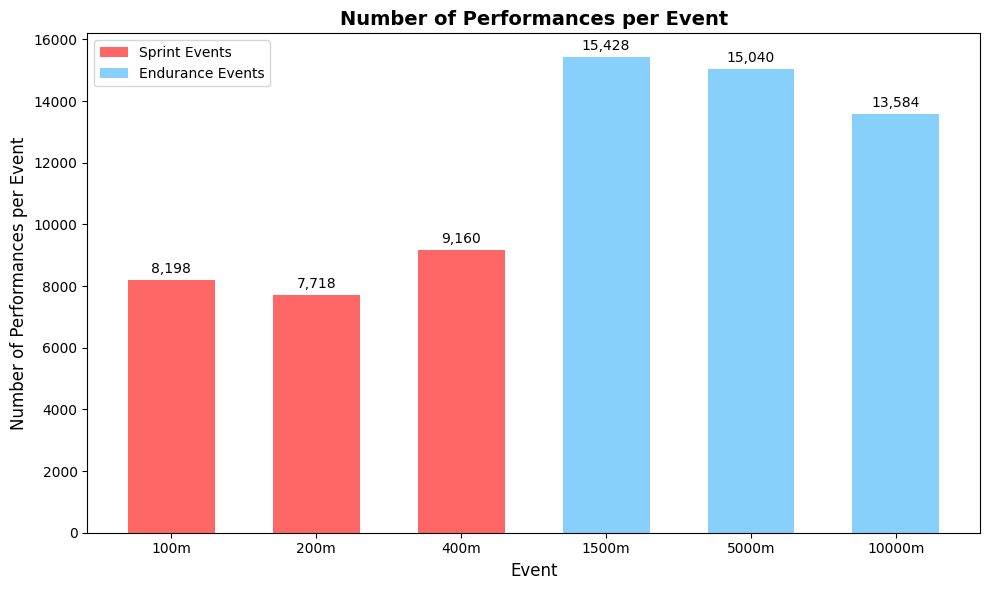

In [45]:
# To help visualise how much data I have per event, I'm going to create a bar chart.

event_counts = df_clean["Event"].value_counts()
event_counts = event_counts.reindex(event_order)

fig, ax = plt.subplots(figsize = (10, 6))
colours = ["#ff6666", "#ff6666", "#ff6666", "#88d0fc", "#88d0fc", "#88d0fc"]
bars = ax.bar(event_order, event_counts.values, width = 0.6, color = colours)
ax.bar_label(bars, fmt = "{:,.0f}", padding = 3)
ax.set_title("Number of Performances per Event", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Event", fontsize = 12)
ax.set_ylabel("Number of Performances per Event", fontsize = 12)
legend_elements = [Patch(facecolor = "#ff6666", label = "Sprint Events"), Patch(facecolor = "#88d0fc", label = "Endurance Events")]
ax.legend(handles = legend_elements, loc = "upper left")
                    

plt.tight_layout()
plt.savefig("figures/event_counts.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [46]:
# I'm also going to create a grouped bar chart showing number of performances per event per gender

gender_counts = df_clean.groupby(["Event", "Gender"]).size().unstack(fill_value = 0)
gender_counts = gender_counts.loc[event_order]

print(gender_counts)

Gender  Female   Male
Event                
100m      3385   4813
200m      2716   5002
400m      4103   5057
1500m     3799  11629
5000m     5531   9509
10000m    2665  10919


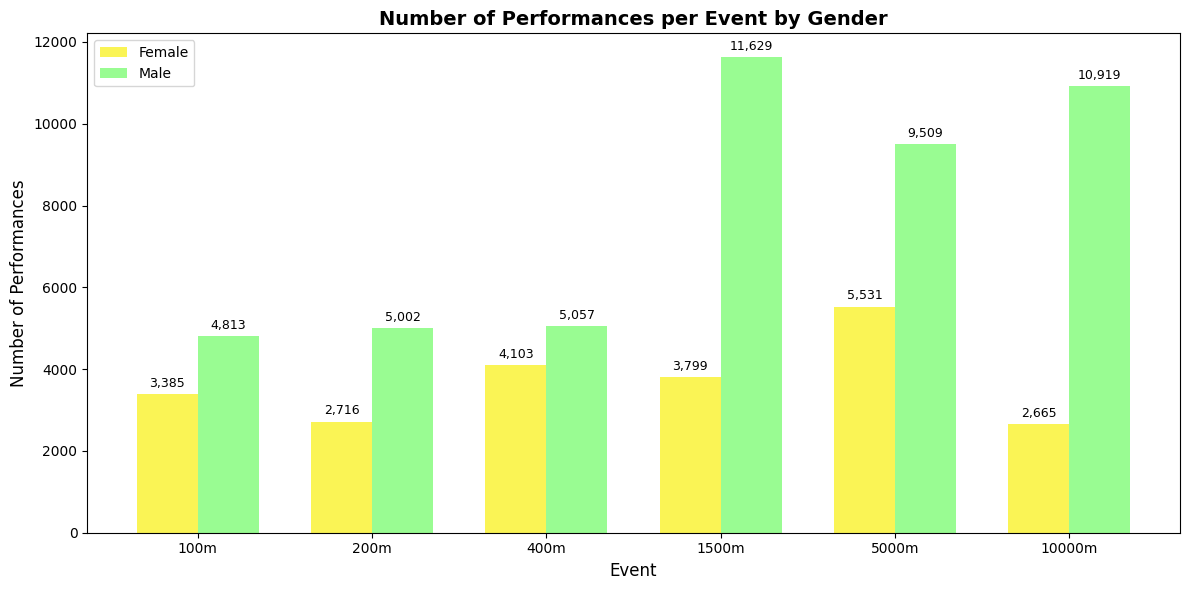

In [47]:
fig, ax = plt.subplots(figsize = (12, 6))

x = np.arange(len(event_order))
width = 0.35

bars_f = ax.bar(x - width/2, gender_counts["Female"], width, color = "#faf455", label = "Female")
bars_m = ax.bar(x + width/2, gender_counts["Male"], width, color = "#99fc92", label = "Male")
ax.bar_label(bars_f, fmt = "{:,.0f}", padding = 3, fontsize = 9)
ax.bar_label(bars_m, fmt = "{:,.0f}", padding = 3, fontsize = 9)

ax.set_xticks(x)
ax.set_xticklabels(event_order)

ax.set_title("Number of Performances per Event by Gender", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Event", fontsize = 12)
ax.set_ylabel("Number of Performances", fontsize = 12)
ax.legend(loc = "upper left")

plt.tight_layout()
plt.savefig("figures/events_counts_by_gender.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [48]:
# What years are available in the dataset?

year_counts = df_clean["Year"].value_counts()
year_counts

Year
2025    3952
2024    3860
2023    3409
2022    3003
2021    2683
        ... 
1964       8
1960       4
1958       2
1963       2
1962       1
Name: count, Length: 67, dtype: int64

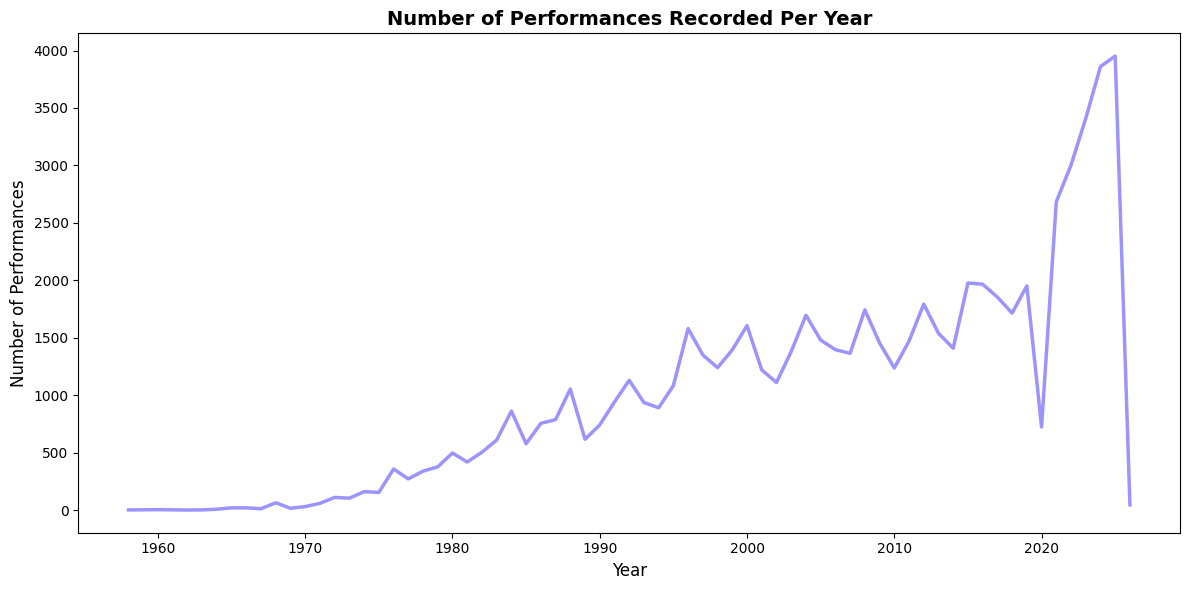

In [49]:
# Create a graph of how much data per year:

year_counts = df_clean.groupby("Year").size().reset_index(name = "Count")

fig, ax = plt.subplots(figsize = (12, 6))
ax.plot(year_counts["Year"], year_counts["Count"], color = "#9b94ff", linewidth = 2.5)
ax.set_title("Number of Performances Recorded Per Year", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Number of Performances", fontsize = 12)

plt.tight_layout()
plt.savefig("figures/performances_per_year.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [50]:
# What are the lower quartile, median and upper quartile of the year counts?

year_counts.quantile([0.25, 0.5, 0.75])

,Year,Count
0.25,1976.5,216.5
0.50,1993.0,936.0
0.75,2009.5,1475.5


In [51]:
# I'm going to work with the years that have at least 217 data points per year as 75% of the available years in the dataset have this number

year_counts[year_counts["Count"] < 217]

,Year,Count
0,1958,2
1,1960,4
2,1962,1
3,1963,2
4,1964,8
5,1965,20
6,1966,20
7,1967,12
8,1968,64
9,1969,16


I'll be dropping the years 1958-1975 as well as 2026 because there is not sufficient data points to provide quality analysis.

In [52]:
# Drop the years with insufficient data

years_to_drop = year_counts[year_counts["Count"] < 217]["Year"]
df_clean = df_clean[~df_clean["Year"].isin(years_to_drop)]

In [53]:
# Now what is the minimum count per year?

df_clean["Year"].value_counts().min()

np.int64(272)

In [54]:
# Checking 1961 has no data as it didn't appear in the years with less than 217 counts.

print(year_counts[year_counts["Year"] == 1961])

Empty DataFrame
Columns: [Year, Count]
Index: []


Years with performance counts below the 25th percentile were removed from the dataset. This is because using percentiles is a data-driven approach to excluding years with insufficient performance data for thorough comparison. This removed the first 16 years of data (1958-1975) and 2026. The 2026 season has not been completed at the time of data collection.

In [55]:
# Investigate if there are any outliers

df_clean.groupby(["Event", "Gender"])["Time_seconds"].describe()

count         mean        std      min        25%       50%  \
Event  Gender                                                                  
100m   Female   3382.0    10.990931   0.089761    10.54    10.9400    11.010   
       Male     4800.0    10.015560   0.068979     9.58     9.9800    10.040   
200m   Female   2702.0    22.348675   0.206563    21.34    22.2325    22.400   
       Male     4953.0    20.202499   0.169175    19.19    20.1200    20.250   
400m   Female   4092.0    50.408680   0.496245    47.60    50.1400    50.530   
       Male     5000.0    44.836842   0.315846    43.03    44.6800    44.925   
1500m  Female   3788.0   242.071323   2.514189   228.68   240.7575   242.740   
       Male    11497.0   215.588066   1.994029   206.00   214.5000   216.110   
5000m  Female   5531.0   906.016328  15.228911   838.06   897.2000   909.800   
       Male     9356.0   798.397696   9.570241   755.36   793.0300   800.950   
10000m Female   2665.0  1895.304852  30.484781  1734.14  1879.8700  1903.600   
       Male    10547.0  1683.680564  22.371037  1571.00  1671.6850  1689.470   

                     75%      max  
Event  Gender                      
100m   Female    11.0600    11.09  
       Male      10.0700    10.09  
200m   Female    22.5100    22.59  
       Male      20.3300    20.39  
400m   Female    50.7900    50.99  
       Male      45.0800    45.20  
1500m  Female   244.0025   244.99  
       Male     217.1500   217.99  
5000m  Female   918.4350   924.99  
       Male     805.9725   809.99  
10000m Female  1918.3300  1929.99  
       Male    1701.3050  1709.99

In [56]:
for event in event_order:
    for gender in ["Female", "Male"]:
        event_data = df_clean[(df_clean["Event"] == event) & (df_clean["Gender"] == gender)]["Time_seconds"]
        if len(event_data) == 0:
            continue
            
        Q1 = event_data.quantile(0.25)
        Q3 = event_data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers = event_data[(event_data < lower_bound) | (event_data > upper_bound)]

        print("{} {}: {} outliers (below {:.2f} or above {:.2f})".format(event, gender, len(outliers), lower_bound, upper_bound))

100m Female: 79 outliers (below 10.76 or above 11.24)
100m Male: 136 outliers (below 9.85 or above 10.21)
200m Female: 63 outliers (below 21.82 or above 22.93)
200m Male: 165 outliers (below 19.81 or above 20.64)
400m Female: 98 outliers (below 49.17 or above 51.77)
400m Male: 145 outliers (below 44.08 or above 45.68)
1500m Female: 97 outliers (below 235.89 or above 248.87)
1500m Male: 266 outliers (below 210.52 or above 221.12)
5000m Female: 70 outliers (below 865.35 or above 950.29)
5000m Male: 161 outliers (below 773.62 or above 825.39)
10000m Female: 75 outliers (below 1822.18 or above 1976.02)
10000m Male: 274 outliers (below 1627.26 or above 1745.73)


In [57]:
# Given the nature of the data, the outliers are likely to be exceptionally fast athletes or slower athletes

for event in event_order:
    for gender in ["Female", "Male"]:
        event_data = df_clean[(df_clean["Event"] == event) & (df_clean["Gender"] == gender)]["Time_seconds"]
            
        Q1 = event_data.quantile(0.25)
        Q3 = event_data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        too_fast = event_data[event_data < lower_bound]
        too_slow = event_data[event_data > upper_bound]

        print("{} {}: {} suspiciously fast performances, {} slower performances".format(event, gender, len(too_fast), len(too_slow)))

100m Female: 79 suspiciously fast performances, 0 slower performances
100m Male: 136 suspiciously fast performances, 0 slower performances
200m Female: 63 suspiciously fast performances, 0 slower performances
200m Male: 165 suspiciously fast performances, 0 slower performances
400m Female: 98 suspiciously fast performances, 0 slower performances
400m Male: 145 suspiciously fast performances, 0 slower performances
1500m Female: 97 suspiciously fast performances, 0 slower performances
1500m Male: 266 suspiciously fast performances, 0 slower performances
5000m Female: 70 suspiciously fast performances, 0 slower performances
5000m Male: 161 suspiciously fast performances, 0 slower performances
10000m Female: 75 suspiciously fast performances, 0 slower performances
10000m Male: 274 suspiciously fast performances, 0 slower performances


**Outlier analysis:**  
All of the outliers within my data are below the lower bound. I'm not going to remove these given the nature of my dataset. My dataset contains the all-time best athletics performances so is naturally going to be heavily skewed towards the faster times. The best performances (world records or near world records) are exceptional and are always going to fall below the lower bound, but they are not data errors. Removing these outliers would risk discarding the most significant data in my dataset.

In [58]:
# What does the dataset look like now that I've cleaned it

df_clean.head()

,Rank,Time,Athlete,Year,Event,Gender,Time_seconds
20366,1561,11.01,Annegret Richter,1976,100m,Female,11.01
20847,2045,11.04,Ingeborg Helten,1976,100m,Female,11.04
21028,2226,11.05,Annegret Richter,1976,100m,Female,11.05
21202,2402,11.06,Annegret Richter,1976,100m,Female,11.06
21677,2883,11.08,Brenda Morehead,1976,100m,Female,11.08


In [59]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 68313 entries, 20366 to 69107
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Rank          68313 non-null  int64   
 1   Time          68313 non-null  str     
 2   Athlete       68313 non-null  str     
 3   Year          68313 non-null  int64   
 4   Event         68313 non-null  category
 5   Gender        68313 non-null  str     
 6   Time_seconds  68313 non-null  float64 
dtypes: category(1), float64(1), int64(2), str(3)
memory usage: 3.7 MB


In [60]:
# Save the cleaned data to a CSV

df_clean.to_csv("data/processed/athletics_clean.csv", index = False)
print("Saved cleaned data!")

Saved cleaned data!


## Data analysis

In [61]:
!pip install scipy --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [62]:
from scipy import stats

In [63]:
# Load the cleaned data CSV
df_clean = pd.read_csv("data/processed/athletics_clean.csv")
df_clean.info()

# Create a copy of the original DataFrame
df_analysis = df_clean.copy()

<class 'pandas.DataFrame'>
RangeIndex: 68313 entries, 0 to 68312
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          68313 non-null  int64  
 1   Time          68313 non-null  str    
 2   Athlete       68313 non-null  str    
 3   Year          68313 non-null  int64  
 4   Event         68313 non-null  str    
 5   Gender        68313 non-null  str    
 6   Time_seconds  68313 non-null  float64
dtypes: float64(1), int64(2), str(4)
memory usage: 3.6 MB


In [64]:
# Order events again

df_analysis["Event"] = pd.Categorical(df_analysis["Event"], categories = event_order, ordered = True)
df_analysis.sort_values(by = ["Gender", "Event", "Year"], ascending = [True, True, True], inplace = True)

### Exploring trends

#### Trends across time

I'm going to begin the data analysis by exploring trends across time in each event for both men and women.

In [65]:
# Gather the minimum (fastest) time per event in each year for both men and women

min_times = (df_analysis.groupby(["Event", "Gender", "Year"])["Time_seconds"].min().reset_index())
min_times.head()

,Event,Gender,Year,Time_seconds
0,100m,Female,1976,11.01
1,100m,Female,1977,10.88
2,100m,Female,1978,10.94
3,100m,Female,1979,10.97
4,100m,Female,1980,10.93


I've used the fastest time from each year rather than the average (for example) because it directly reflects the progression of athletic performance, which is the focus of my analysis. Average time is influenced by participation rates. Also, my dataset contains the all-time best performances, so the average of my dataset does not represent the average athlete.

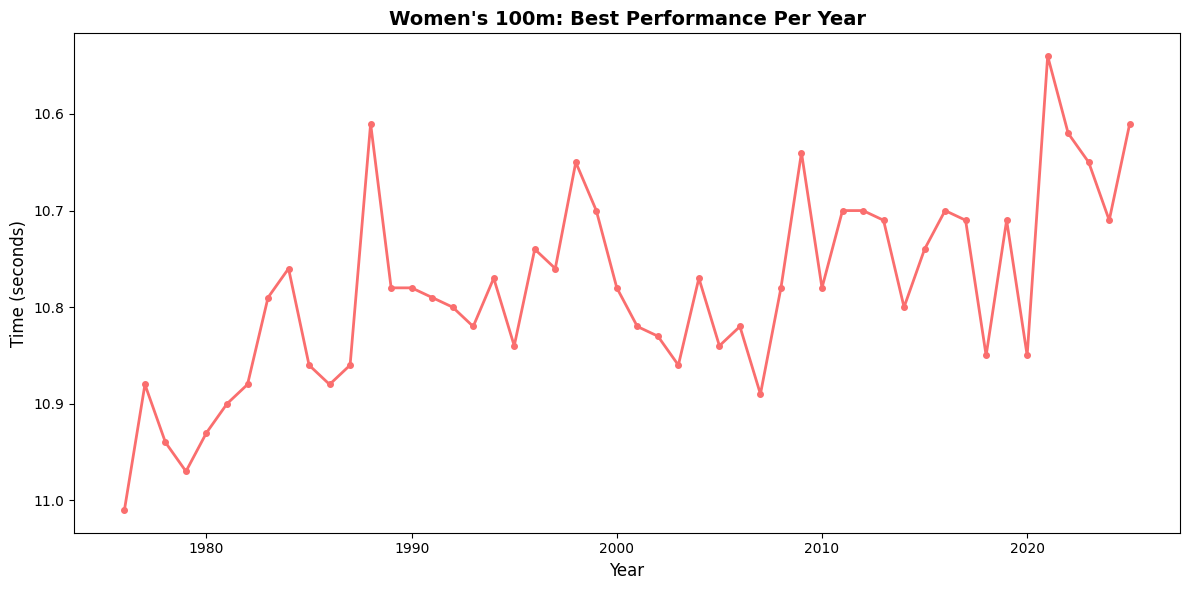

In [66]:
# Test plotting by only plotting female 100m performances against time

df_100m_f = min_times[(min_times["Event"] == "100m") & (min_times["Gender"] == "Female")]

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(df_100m_f["Year"], df_100m_f["Time_seconds"], color = "#fa6e6e", linewidth = 2, marker = "o", markersize = 4)
ax.set_title("Women's 100m: Best Performance Per Year", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Time (seconds)", fontsize = 12)
# Invert the y-axis so faster times appear higher on the plot, more intuitive to look at as faster time = better
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("figures/100mW_progression.png", dpi = 150, bbox_inches = "tight")
plt.show()

There is a problem when I attempt to plot female performances from all events onto one plot: time scale. 100m is approximately 11 seconds compared to 10,000m at approximately 1900 seconds. All events will not be readable on the same y-axis.  
A solution is to calculate percentage improvement in each event compared to the first year.

In [67]:
# Calculate percentage improvement in each event relative to the first year

min_times_pct = min_times.copy()

for event in min_times_pct["Event"].unique():
    for gender in min_times_pct["Gender"].unique():
        mins = (min_times_pct["Event"] == event) & (min_times_pct["Gender"] == gender)
        if mins.sum() == 0:
            continue
        baseline = min_times_pct[mins]["Time_seconds"].iloc[0]
        min_times_pct.loc[mins, "Percentage_improvement"] = ((baseline - min_times_pct.loc[mins, "Time_seconds"]) / baseline * 100)

min_times_pct

,Event,Gender,Year,Time_seconds,Percentage_improvement
0,100m,Female,1976,11.01,0.000000
1,100m,Female,1977,10.88,1.180745
2,100m,Female,1978,10.94,0.635786
3,100m,Female,1979,10.97,0.363306
4,100m,Female,1980,10.93,0.726612
...,...,...,...,...,...
584,10000m,Male,2021,1593.93,4.002096
585,10000m,Male,2022,1593.84,4.007516
586,10000m,Male,2023,1610.66,2.994495
587,10000m,Male,2024,1591.01,4.177959


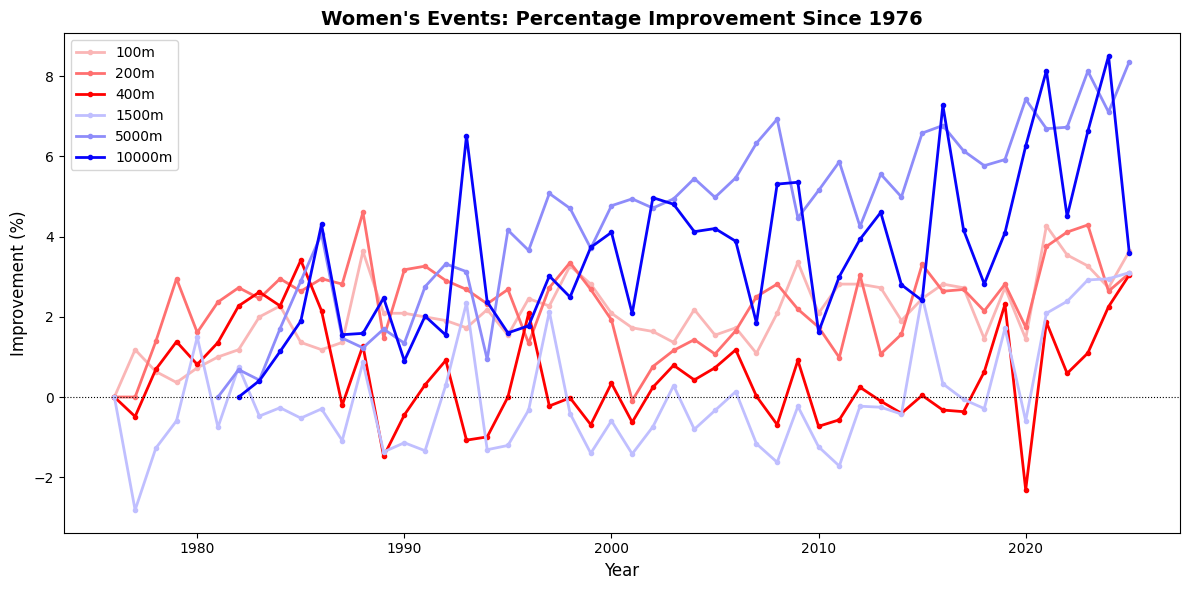

In [68]:
# Plot percentage change in female performance in all events across time.

female_data = min_times_pct[min_times_pct["Gender"] == "Female"]
colours1 = {"100m": "#fab6b6", "200m": "#ff7070", "400m": "#ff0000", "1500m": "#c0bfff", "5000m": "#8e8cfa", "10000m": "#0703fc"}

fig, ax = plt.subplots(figsize = (12, 6))

for event in female_data["Event"].unique():
    event_data = female_data[female_data["Event"] == event]
    ax.plot(event_data["Year"], event_data["Percentage_improvement"], color = colours1[event], linewidth = 2, marker = "o", markersize = 3, label = event)

ax.set_title("Women's Events: Percentage Improvement Since 1976", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Improvement (%)", fontsize = 12)
ax.legend(loc = "upper left")
ax.axhline(0, color = "black", linewidth = 0.8, linestyle = ":")

plt.tight_layout()
plt.savefig("figures/female_events_pct_improvement.png", dpi = 150, bbox_inches = "tight")
plt.show()

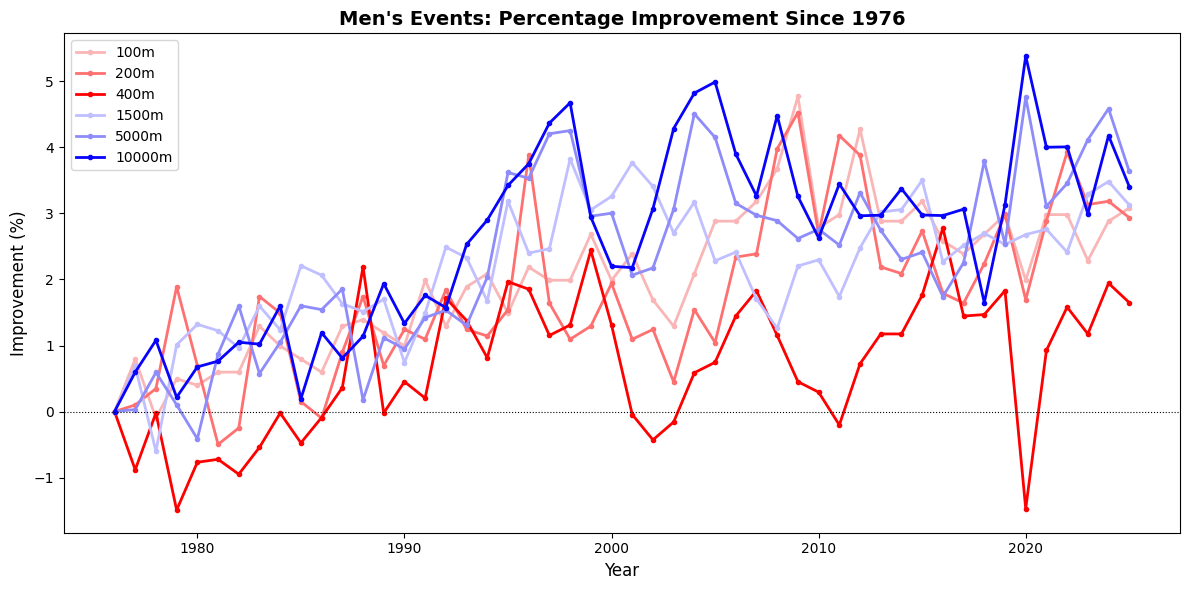

In [69]:
# Plot percentage change in male performance in all events across time.

male_data = min_times_pct[min_times_pct["Gender"] == "Male"]
colours1 = {"100m": "#fab6b6", "200m": "#ff7070", "400m": "#ff0000", "1500m": "#c0bfff", "5000m": "#8e8cfa", "10000m": "#0703fc"}

fig, ax = plt.subplots(figsize = (12, 6))

for event in male_data["Event"].unique():
    event_data = male_data[male_data["Event"] == event]
    ax.plot(event_data["Year"], event_data["Percentage_improvement"], color = colours1[event], linewidth = 2, marker = "o", markersize = 3, label = event)

ax.set_title("Men's Events: Percentage Improvement Since 1976", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Improvement (%)", fontsize = 12)
ax.legend(loc = "upper left")
ax.axhline(0, color = "black", linewidth = 0.8, linestyle = ":")

plt.tight_layout()
plt.savefig("figures/male_events_pct_improvement.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [ ]:
# Combine female and male percentage change in performance onto one figure
# I'm going to combine events into sprint and endurance rather than plot each individual event otherwise the graph would be too crowded

fig, ax = plt.subplots(figsize = (12, 6))

line_styles = {"Female": "-", "Male: "--"}